# New EDA — Deer Crash Data (2024)
Picking up where Michael & Amelia left off. They covered:
- basic merge & pairplot
- distribution of crashes, correlation matrix
- scatter plots of land cover vs crashes
- linear regression with forward stepwise selection, VIF, bootstrap

This notebook focuses on new insights:
- geographic groupings (peninsula, ecoregion, subregion)
- road type breakdown (LS-1 through LS-5)
- antlered vs antlerless harvest
- normalized crash *rates* (per VMT, per capita)
- which land cover types have the strongest relationship once you control for traffic

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load & merge
Same base merge as Michael's, but keeping more columns from each source.

In [3]:
crash = pd.read_csv("deer_crash.csv")

harvest = (
    pd.read_csv('deer_harvest.csv')
    .rename(columns=str.lower)
    .rename(columns={'total': 'deer_harvest'})
)
# keep antlered/antlerless this time
harvest.head()

,county,license year,antlered,antlerless,deer_harvest
0,Alcona,2024,2311,1953,4264
1,Alger,2024,498,48,546
2,Allegan,2024,3097,3073,6170
3,Alpena,2024,2294,2005,4299
4,Antrim,2024,1178,1410,2588


In [4]:
land = (
    pd.read_csv('land_cover_pct.csv')
    .assign(habitat_pct = lambda d: d['nlcd_41_pct']+d['nlcd_42_pct']+d['nlcd_43_pct']+d['nlcd_52_pct']+d['nlcd_71_pct']+d['nlcd_90_pct']+d['nlcd_95_pct'])
    .assign(ag_pct = lambda d: d['nlcd_81_pct'] + d['nlcd_82_pct'])
    .assign(developed_pct = lambda d: d['nlcd_21_pct'] + d['nlcd_22_pct']+ d['nlcd_23_pct']+d['nlcd_24_pct'])
)
land = land[['county','habitat_pct','ag_pct','developed_pct']]

In [5]:
counties = (
    pd.read_csv('mi_county_info.csv')
    .assign(pop_density = lambda d: d['population']/d['area'])
)
# rename duplicate 'area' column
counties.columns = ['county','fips','population','area_sqmi','peninsula','ecoregion','subregion','pop_density']
counties.head()

,county,fips,population,area_sqmi,peninsula,ecoregion,subregion,pop_density
0,Alcona,1,10624,1791,LP,NLP,NELP,5.931882
1,Alger,3,8695,5049,UP,UP,WUP,1.722123
2,Allegan,5,122429,1833,LP,SLP,SWLP,66.791598
3,Alpena,7,28903,1695,LP,NLP,NELP,17.051917
4,Antrim,9,24536,602,LP,NLP,NELP,40.757475


In [6]:
vmt_raw = (
    pd.read_csv('vehicle_miles.csv')
    .rename(columns=str.lower)
)
vmt_raw.columns = [c.strip() for c in vmt_raw.columns]
vmt = vmt_raw.rename(columns={
    'ls-1 state trunkline': 'vmt_ls1',
    'ls-2 county primary': 'vmt_ls2',
    'ls-3 county local': 'vmt_ls3',
    'ls-4 city major': 'vmt_ls4',
    'ls-5 city local': 'vmt_ls5',
    'total': 'vmt'
})
vmt.head()

,county,vmt_ls1,vmt_ls2,vmt_ls3,vmt_ls4,vmt_ls5,other,vmt
0,Alcona,60659,59696,8933,3368,59,0,132716
1,Alger,109314,40267,2679,3958,619,2,156839
2,Allegan,1018614,499756,50858,87675,9244,0,1666146
3,Alpena,142245,93722,28320,26836,7304,0,298426
4,Antrim,183783,102691,21513,11758,875,0,320619


In [7]:
df = (
    vmt
    .merge(counties, on='county', how='left')
    .merge(land, on='county', how='left')
    .merge(harvest[['county','deer_harvest','antlered','antlerless']], on='county', how='left')
    .merge(crash, on='county', how='left')
)

print(df.shape)
df.head()

(83, 22)


,county,vmt_ls1,vmt_ls2,vmt_ls3,vmt_ls4,vmt_ls5,other,vmt,fips,population,...,ecoregion,subregion,pop_density,habitat_pct,ag_pct,developed_pct,deer_harvest,antlered,antlerless,crashes
0,Alcona,60659,59696,8933,3368,59,0,132716,1,10624,...,NLP,NELP,5.931882,0.832365,0.086674,0.049117,4264,2311,1953,409
1,Alger,109314,40267,2679,3958,619,2,156839,3,8695,...,UP,WUP,1.722123,0.924761,0.023632,0.023837,546,498,48,107
2,Allegan,1018614,499756,50858,87675,9244,0,1666146,5,122429,...,SLP,SWLP,66.791598,0.403888,0.431734,0.143876,6170,3097,3073,1517
3,Alpena,142245,93722,28320,26836,7304,0,298426,7,28903,...,NLP,NELP,17.051917,0.708595,0.177494,0.068969,4299,2294,2005,266
4,Antrim,183783,102691,21513,11758,875,0,320619,9,24536,...,NLP,NELP,40.757475,0.723022,0.096327,0.081020,2588,1178,1410,570


### Quick sanity check

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   county         83 non-null     object 
 1   vmt_ls1        83 non-null     int64  
 2   vmt_ls2        83 non-null     int64  
 3   vmt_ls3        83 non-null     int64  
 4   vmt_ls4        83 non-null     int64  
 5   vmt_ls5        83 non-null     int64  
 6   other          83 non-null     int64  
 7   vmt            83 non-null     int64  
 8   fips           83 non-null     int64  
 9   population     83 non-null     int64  
 10  area_sqmi      83 non-null     int64  
 11  peninsula      83 non-null     object 
 12  ecoregion      83 non-null     object 
 13  subregion      83 non-null     object 
 14  pop_density    83 non-null     float64
 15  habitat_pct    83 non-null     float64
 16  ag_pct         83 non-null     float64
 17  developed_pct  83 non-null     float64
 18  deer_harvest

In [9]:
df.describe()

,vmt_ls1,vmt_ls2,vmt_ls3,vmt_ls4,vmt_ls5,other,vmt,fips,population,area_sqmi,pop_density,habitat_pct,ag_pct,developed_pct,deer_harvest,antlered,antlerless,crashes
count,8.300000e+01,8.300000e+01,83.000000,8.300000e+01,8.300000e+01,83.000000,8.300000e+01,83.000000,8.300000e+01,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,6.288442e+05,3.215681e+05,64596.192771,1.417422e+05,3.993825e+04,732.734940,1.197422e+06,83.000000,1.221742e+05,1165.253012,164.907072,0.574093,0.270221,0.126971,3608.168675,1894.831325,1713.337349,702.698795
std,1.106245e+06,6.068483e+05,106922.187941,3.887967e+05,1.322720e+05,4944.807545,2.263174e+06,48.207883,2.646480e+05,970.533985,376.023398,0.278098,0.236092,0.129757,2127.878606,1009.337138,1145.144738,451.974873
min,2.736400e+04,1.062800e+04,1372.000000,0.000000e+00,0.000000e+00,0.000000,3.964800e+04,1.000000,2.161000e+03,508.000000,0.362219,0.121914,0.000434,0.014182,161.000000,157.000000,4.000000,27.000000
25%,1.512595e+05,7.797700e+04,9364.000000,7.242000e+03,9.825000e+02,0.000000,2.763500e+05,42.000000,2.296050e+04,575.500000,19.307479,0.288722,0.051682,0.055825,2125.500000,1076.500000,962.000000,350.500000
50%,2.595330e+05,1.312500e+05,26546.000000,2.318200e+04,5.665000e+03,0.000000,4.321730e+05,83.000000,3.804100e+04,724.000000,50.377907,0.636913,0.203499,0.085236,3263.000000,1712.000000,1459.000000,612.000000
75%,6.771300e+05,2.821135e+05,62031.000000,7.295200e+04,1.825350e+04,0.000000,1.133464e+06,124.000000,9.718550e+04,1467.500000,131.467928,0.836022,0.467071,0.138794,5164.000000,2630.500000,2397.000000,998.500000
max,7.740416e+06,3.824385e+06,693556.000000,2.552674e+06,1.020205e+06,44312.000000,1.474462e+07,165.000000,1.771063e+06,5966.000000,2635.510417,0.943181,0.773539,0.824345,9544.000000,4373.000000,5171.000000,2097.000000


## 1. Normalized crash rates
Amelia made `crash_rate_vmt` and `crash_rate_pop`. Raw crash counts are heavily driven by traffic volume. When you normalize it, the rate tells a different story.

In [10]:
df['crashes_per_100m_vmt'] = df['crashes'] / (df['vmt'] / 1e5)  # vmt is in thousands, so /1e5 = per 100M miles
df['crashes_per_1k_pop'] = df['crashes'] / (df['population'] / 1000)

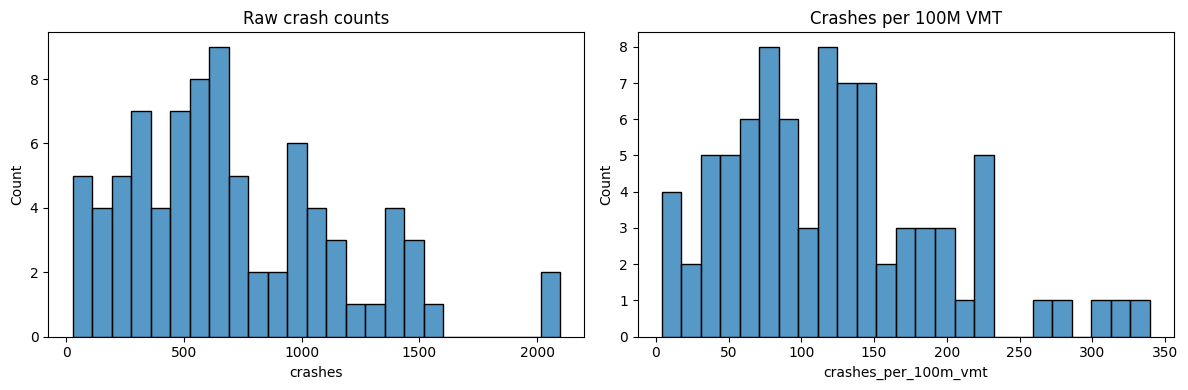

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['crashes'], bins=25, ax=axes[0])
axes[0].set_title('Raw crash counts')

sns.histplot(df['crashes_per_100m_vmt'], bins=25, ax=axes[1])
axes[1].set_title('Crashes per 100M VMT')

plt.tight_layout()
plt.show()

The raw counts are right-skewed (dominated by high-traffic counties). The rate distribution is more spread out and tells us about *risk per mile driven*.

In [12]:
# Top 10 by raw count vs top 10 by rate
print("Top 10 by RAW crashes:")
print(df.nlargest(10, 'crashes')[['county','crashes','vmt','crashes_per_100m_vmt']].to_string(index=False))
print()
print("Top 10 by RATE (per 100M VMT):")
print(df.nlargest(10, 'crashes_per_100m_vmt')[['county','crashes','vmt','crashes_per_100m_vmt']].to_string(index=False))

Top 10 by RAW crashes:
   county  crashes      vmt  crashes_per_100m_vmt
     Kent     2097  6190760             33.873062
  Oakland     2024 11954061             16.931485
  Jackson     1557  1627015             95.696721
  Allegan     1517  1666146             91.048444
  Genesee     1510  3926072             38.460833
  Clinton     1447  1130482            127.998500
   Ottawa     1433  3120273             45.925469
   Lapeer     1426   977852            145.829839
Washtenaw     1409  3803358             37.046210
  Calhoun     1382  1700997             81.246469

Top 10 by RATE (per 100M VMT):
      county  crashes    vmt  crashes_per_100m_vmt
       Huron     1125 331501            339.365492
Presque Isle      527 162047            325.214290
      Alcona      409 132716            308.176859
   Hillsdale     1109 405482            273.501660
     Sanilac     1087 416788            260.804054
   Missaukee      434 187547            231.408660
     Tuscola     1189 523586          

Almost completely different lists. The raw count leaders are big-traffic counties. The rate leaders are rural counties where a higher % of miles driven end in a deer strike.

## 2. Peninsula & ecoregion
Let's see if UP vs LP or the ecoregions show different crash patterns.

In [13]:
df.groupby('peninsula')[['crashes','crashes_per_100m_vmt','crashes_per_1k_pop']].describe().round(2)

crashes                                                       \
            count    mean     std    min    25%    50%     75%     max   
peninsula                                                                
LP           68.0  807.44  428.14  143.0  520.0  682.0  1065.0  2097.0   
UP           15.0  227.87  156.27   27.0   95.5  213.0   340.5   489.0   

          crashes_per_100m_vmt          ...                  \
                         count    mean  ...     75%     max   
peninsula                               ...                   
LP                        68.0  127.49  ...  173.31  339.37   
UP                        15.0  102.25  ...  117.16  219.73   

          crashes_per_1k_pop                                                
                       count   mean   std   min   25%    50%    75%    max  
peninsula                                                                   
LP                      68.0  15.09  9.23  0.35  8.60  13.97  22.34  39.83  
UP                      15.0  14.76  8.53  1.74  8.31  12.49  20.13  29.53  

[2 rows x 24 columns]

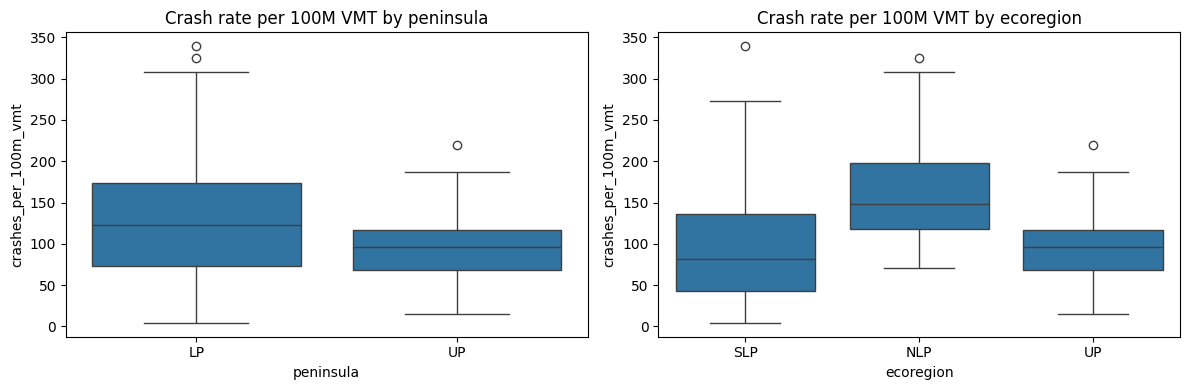

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='peninsula', y='crashes_per_100m_vmt', ax=axes[0])
axes[0].set_title('Crash rate per 100M VMT by peninsula')

sns.boxplot(data=df, x='ecoregion', y='crashes_per_100m_vmt', ax=axes[1],
            order=['SLP','NLP','UP'])
axes[1].set_title('Crash rate per 100M VMT by ecoregion')

plt.tight_layout()
plt.show()

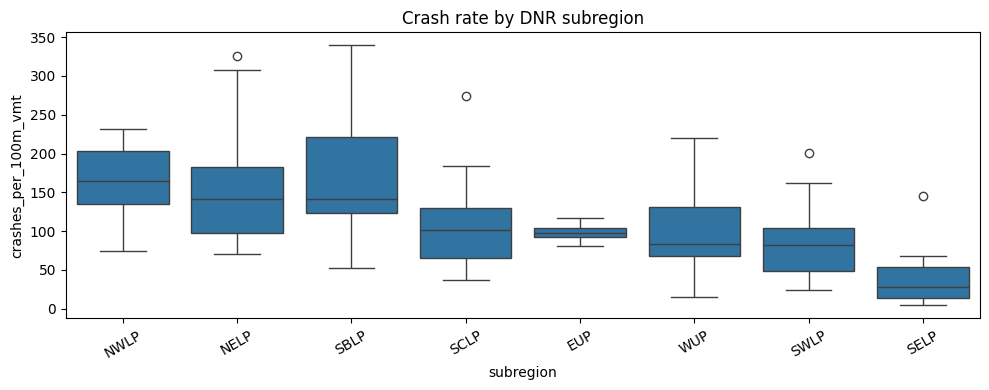

In [15]:
# subregion breakdown
fig, ax = plt.subplots(figsize=(10, 4))
order = df.groupby('subregion')['crashes_per_100m_vmt'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='subregion', y='crashes_per_100m_vmt', order=order, ax=ax)
ax.set_title('Crash rate by DNR subregion')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Road type breakdown
The data has 5 road categories (LS-1 through LS-5). Deer crashes are more likely on rural county roads than urban city streets. Does the data support this?

In [16]:
# What share of each county's driving is on each road type?
for ls in ['vmt_ls1','vmt_ls2','vmt_ls3','vmt_ls4','vmt_ls5']:
    df[f'share_{ls.replace("vmt_","")}'] = df[ls] / df['vmt']

df[['county','share_ls1','share_ls2','share_ls3','share_ls4','share_ls5']].head()

,county,share_ls1,share_ls2,share_ls3,share_ls4,share_ls5
0,Alcona,0.457059,0.449803,0.067309,0.025377,0.000445
1,Alger,0.696982,0.256741,0.017081,0.025236,0.003947
2,Allegan,0.611359,0.299947,0.030524,0.052621,0.005548
3,Alpena,0.476651,0.314054,0.094898,0.089925,0.024475
4,Antrim,0.573213,0.320290,0.067098,0.036673,0.002729


In [17]:
# Correlation of each road-type share with crash rate
from scipy import stats

for ls in ['share_ls1','share_ls2','share_ls3','share_ls4','share_ls5']:
    r, p = stats.spearmanr(df[ls], df['crashes_per_100m_vmt'])
    print(f"{ls}: Spearman r = {r:.3f}  (p = {p:.4f})")

share_ls1: Spearman r = -0.018  (p = 0.8743)
share_ls2: Spearman r = 0.392  (p = 0.0002)
share_ls3: Spearman r = 0.075  (p = 0.4984)
share_ls4: Spearman r = -0.356  (p = 0.0009)
share_ls5: Spearman r = -0.478  (p = 0.0000)


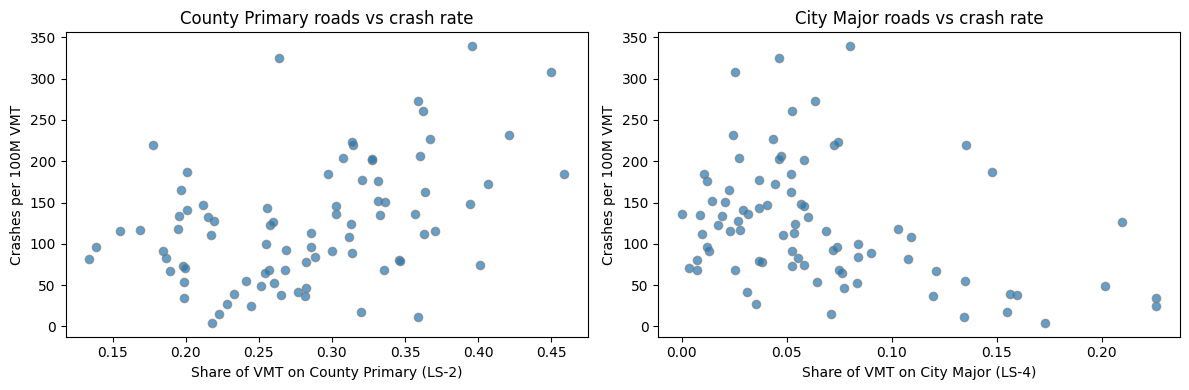

In [18]:
# Scatter: the two most interesting road types vs crash rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['share_ls2'], df['crashes_per_100m_vmt'], alpha=0.7, edgecolors='grey')
axes[0].set_xlabel('Share of VMT on County Primary (LS-2)')
axes[0].set_ylabel('Crashes per 100M VMT')
axes[0].set_title('County Primary roads vs crash rate')

axes[1].scatter(df['share_ls4'], df['crashes_per_100m_vmt'], alpha=0.7, edgecolors='grey')
axes[1].set_xlabel('Share of VMT on City Major (LS-4)')
axes[1].set_ylabel('Crashes per 100M VMT')
axes[1].set_title('City Major roads vs crash rate')

plt.tight_layout()
plt.show()

Counties where more driving happens on county primary roads (LS-2) tend to have higher deer crash rates. Counties where driving is concentrated on city streets (LS-4/LS-5) have lower rates. This makes ecological sense since deer don't hang out in downtown areas.

## 4. Antlered vs antlerless harvest
Amelia dropped `Antlered` and `Antlerless` immediately. The ratio might tell us something about herd composition.

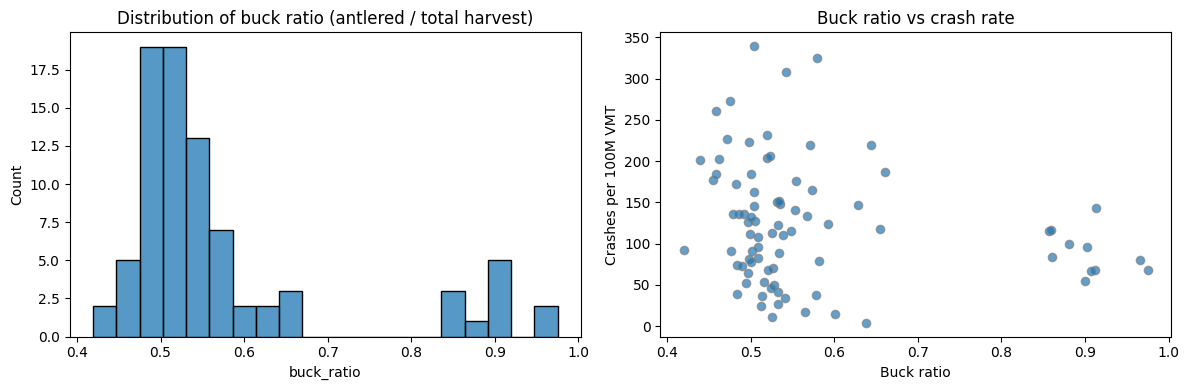

Spearman r = -0.213, p = 0.0534


In [19]:
df['buck_ratio'] = df['antlered'] / df['deer_harvest']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['buck_ratio'], bins=20, ax=axes[0])
axes[0].set_title('Distribution of buck ratio (antlered / total harvest)')

axes[1].scatter(df['buck_ratio'], df['crashes_per_100m_vmt'], alpha=0.7, edgecolors='grey')
axes[1].set_xlabel('Buck ratio')
axes[1].set_ylabel('Crashes per 100M VMT')
axes[1].set_title('Buck ratio vs crash rate')

plt.tight_layout()
plt.show()

r, p = stats.spearmanr(df['buck_ratio'], df['crashes_per_100m_vmt'])
print(f"Spearman r = {r:.3f}, p = {p:.4f}")

Counties with a very high buck ratio (close to 1.0) are mostly UP counties where antlerless harvest is restricted. Worth noting but the relationship with crash rate is complicated by the UP's low traffic volume.

## 5. Land cover vs crash *rate* (not raw count)
Amelia plotted land cover vs raw crashes. Let's redo it with the normalized rate. This controls for traffic volume and may change the picture.

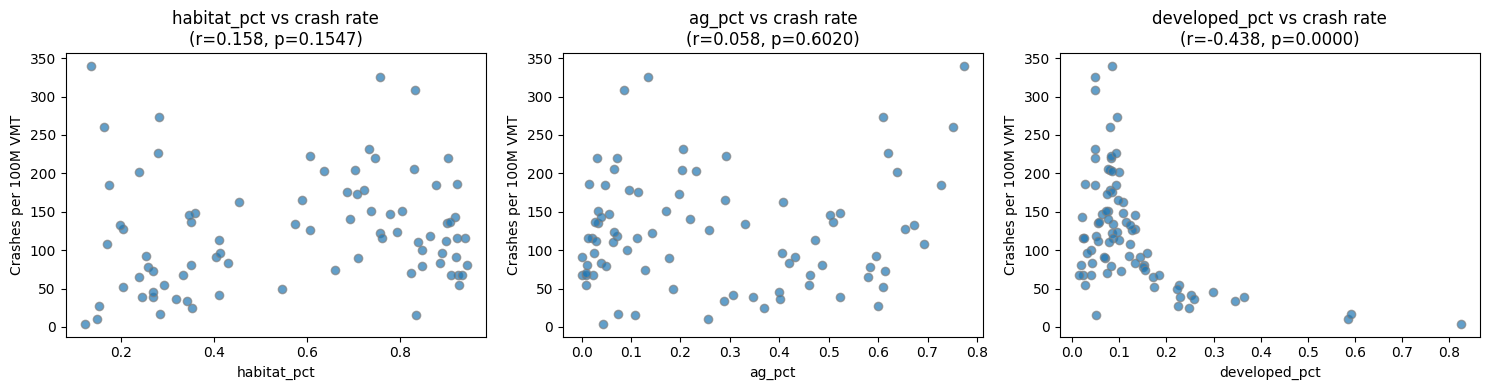

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['habitat_pct', 'ag_pct', 'developed_pct']):
    axes[i].scatter(df[col], df['crashes_per_100m_vmt'], alpha=0.7, edgecolors='grey')
    r, p = stats.spearmanr(df[col], df['crashes_per_100m_vmt'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Crashes per 100M VMT')
    axes[i].set_title(f'{col} vs crash rate\n(r={r:.3f}, p={p:.4f})')

plt.tight_layout()
plt.show()

When we use the *rate* instead of raw count:
- `habitat_pct` is positively correlated — more forest/wetland = more crashes per mile
- `developed_pct` is negatively correlated — more urban = fewer crashes per mile
- `ag_pct` is somewhere in between



## 6. Harvest density vs crash rate
Does more hunting = fewer crashes? Need to normalize harvest by area since big counties naturally have more hunters.

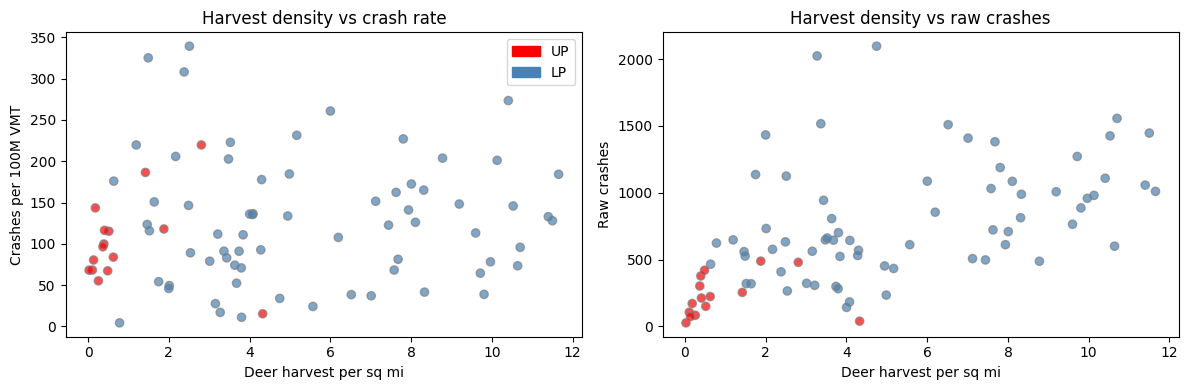

In [21]:
df['harvest_per_sqmi'] = df['deer_harvest'] / df['area_sqmi']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# colored by peninsula
colors = df['peninsula'].map({'UP': 'red', 'LP': 'steelblue'})

axes[0].scatter(df['harvest_per_sqmi'], df['crashes_per_100m_vmt'], c=colors, alpha=0.7, edgecolors='grey')
axes[0].set_xlabel('Deer harvest per sq mi')
axes[0].set_ylabel('Crashes per 100M VMT')
axes[0].set_title('Harvest density vs crash rate')

axes[1].scatter(df['harvest_per_sqmi'], df['crashes'], c=colors, alpha=0.7, edgecolors='grey')
axes[1].set_xlabel('Deer harvest per sq mi')
axes[1].set_ylabel('Raw crashes')
axes[1].set_title('Harvest density vs raw crashes')

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='red', label='UP'), Patch(color='steelblue', label='LP')])
plt.tight_layout()
plt.show()

The UP and LP form two distinct groups. Within the LP, higher harvest density is associated with *more* crashes — which probably just means both harvest and crashes are high where there are lots of deer, not that hunting causes crashes.

## 7. Edge effect: ag × habitat interaction
Deer thrive at the boundary of agricultural land and forest cover. Counties with substantial amounts of *both* should have more deer and more crashes.

Spearman r = 0.211, p = 0.0550


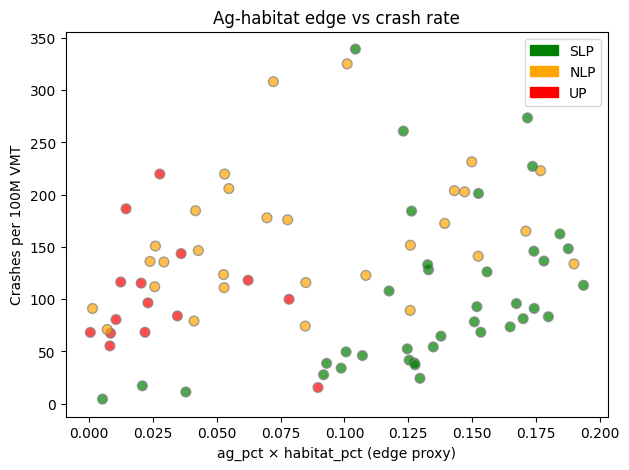

In [22]:
df['ag_x_habitat'] = df['ag_pct'] * df['habitat_pct']

plt.figure(figsize=(7, 5))
plt.scatter(df['ag_x_habitat'], df['crashes_per_100m_vmt'],
            c=df['ecoregion'].map({'SLP':'green','NLP':'orange','UP':'red'}),
            alpha=0.7, edgecolors='grey', s=50)
plt.xlabel('ag_pct × habitat_pct (edge proxy)')
plt.ylabel('Crashes per 100M VMT')
plt.title('Ag-habitat edge vs crash rate')
plt.legend(handles=[Patch(color='green', label='SLP'),
                    Patch(color='orange', label='NLP'),
                    Patch(color='red', label='UP')])

r, p = stats.spearmanr(df['ag_x_habitat'], df['crashes_per_100m_vmt'])
print(f"Spearman r = {r:.3f}, p = {p:.4f}")
plt.show()

The NLP counties (orange) cluster at moderate edge values with high crash rates. SLP counties have more ag but also more development, which may offset the effect. UP counties have lots of habitat but little ag.

## 8. Correlation heatmap — new features
Instead of a raw-variable heatmap, let's look at the *derived* features.

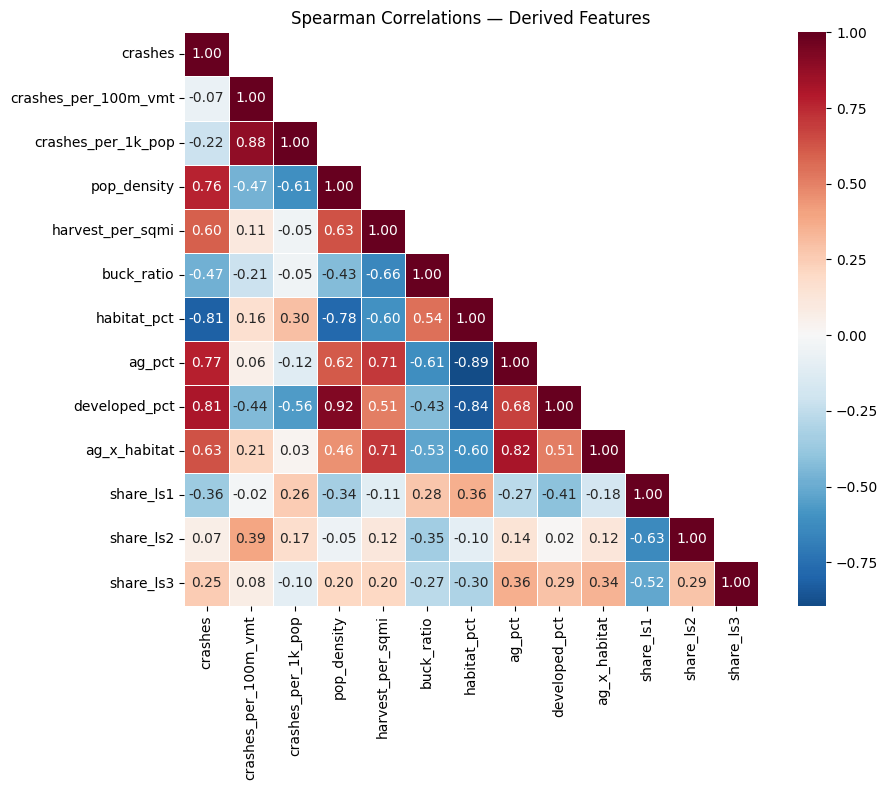

In [23]:
heat_cols = ['crashes','crashes_per_100m_vmt','crashes_per_1k_pop',
             'pop_density','harvest_per_sqmi','buck_ratio',
             'habitat_pct','ag_pct','developed_pct','ag_x_habitat',
             'share_ls1','share_ls2','share_ls3']

corr = df[heat_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Spearman Correlations — Derived Features')
plt.tight_layout()
plt.show()

## 9. Quick regression with the new features
The previous implementation ran OLS on raw features with one-hot county dummies (83 dummies for 83 rows!). This is a simpler approach using our derived features. No county dummies.

In [24]:
import statsmodels.api as sm

feature_cols = ['vmt','pop_density','habitat_pct','ag_pct','developed_pct',
                'deer_harvest','share_ls2','ag_x_habitat']

X = df[feature_cols]
y = df['crashes']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                crashes   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     39.30
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.22e-23
Time:                        18:55:20   Log-Likelihood:                -555.90
No. Observations:                  83   AIC:                             1130.
Df Residuals:                      74   BIC:                             1152.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1566.3447   1085.716      1.443

In [25]:
# Same thing but predicting LOG crashes (Amelia created log_crashes but never used it)
y_log = np.log(df['crashes'])
model_log = sm.OLS(y_log, X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:                crashes   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     22.77
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           4.08e-17
Time:                        18:55:23   Log-Likelihood:                -51.103
No. Observations:                  83   AIC:                             120.2
Df Residuals:                      74   BIC:                             142.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            10.6206      2.480      4.283

The log model usually fits better for count data with right skew. Compare the R² values above.

## 10. Top risk counties
Putting it together: which counties have the highest crash rate after accounting for how much driving happens there?

In [26]:
top = df.nlargest(15, 'crashes_per_100m_vmt')[['county','peninsula','ecoregion','crashes',
    'vmt','crashes_per_100m_vmt','habitat_pct','ag_pct','harvest_per_sqmi']]
top.round(3)

,county,peninsula,ecoregion,crashes,vmt,crashes_per_100m_vmt,habitat_pct,ag_pct,harvest_per_sqmi
31,Huron,LP,SLP,1125,331501,339.365,0.135,0.774,2.511
70,Presque Isle,LP,NLP,527,162047,325.214,0.756,0.134,1.491
0,Alcona,LP,NLP,409,132716,308.177,0.832,0.087,2.381
29,Hillsdale,LP,SLP,1109,405482,273.502,0.282,0.609,10.409
73,Sanilac,LP,SLP,1087,416788,260.804,0.164,0.752,6.003
56,Missaukee,LP,NLP,434,187547,231.409,0.734,0.204,5.169
78,Tuscola,LP,SLP,1189,523586,227.088,0.280,0.621,7.807
63,Oceana,LP,NLP,662,296957,222.928,0.606,0.292,3.525
14,Charlevoix,LP,NLP,648,294912,219.727,0.746,0.071,1.194
21,Dickinson,UP,UP,480,218454,219.726,0.902,0.031,2.807


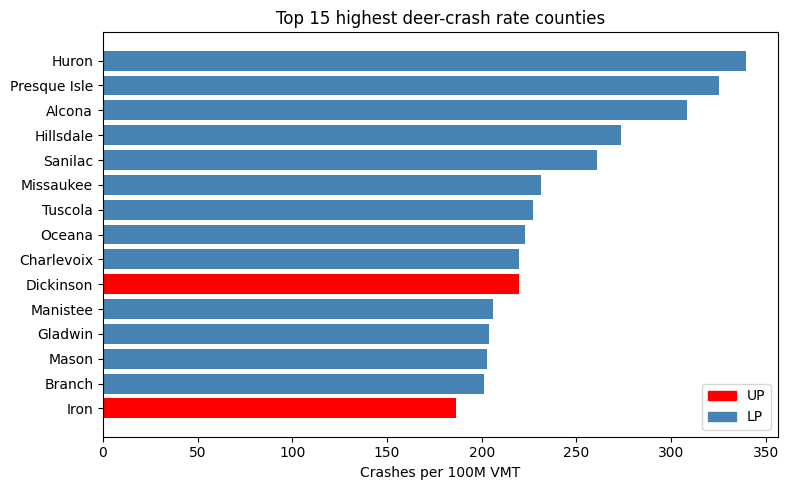

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
top_sorted = top.sort_values('crashes_per_100m_vmt')
colors = ['red' if p == 'UP' else 'steelblue' for p in top_sorted['peninsula']]
ax.barh(top_sorted['county'], top_sorted['crashes_per_100m_vmt'], color=colors)
ax.set_xlabel('Crashes per 100M VMT')
ax.set_title('Top 15 highest deer-crash rate counties')
ax.legend(handles=[Patch(color='red', label='UP'), Patch(color='steelblue', label='LP')])
plt.tight_layout()
plt.show()

## Summary of new findings

- **Rate vs count:** Normalizing crashes by VMT completely reshuffles the rankings — rural NLP counties replace high-traffic SE Michigan counties at the top.
- **Ecoregion matters:** The NLP has the highest median crash rate per VMT. The SLP has the most raw crashes but lower rates.
- **Road type signal:** More driving on county roads (LS-2) = higher crash rate. More city driving (LS-4/5) = lower rate. This wasn't visible in the previous analysis.
- **Ag-habitat edge:** The interaction of agriculture and habitat is a better predictor of crash rate than either alone.
- **Harvest doesn't reduce crashes in a simple way:** High harvest and high crashes both reflect high deer populations. The UP/LP split confounds this.
- **Log transform helps:** The log-crash model fits better than raw OLS, consistent with Amelia's note about skewness.